# Adding a time series encoder

In an attempt to equalize the influence of the time series (dim $\approx 1000$) and the corresponding parameters (dim $\approx 4-400$), we would like to compress the time series. Here we implement a 1d-CNN network. This network can handle variable time sequences, because of the average pooling layer, that returns a single average value for each channel, regardless of sequence length. 

In [ ]:
import sys
sys.path.append('..')

from src.simulator import Model, BurstSimulator
from src.flow_matching.distributions import Prior, Posterior
from src.flow_matching.probability_path import GuidedLinearProbabilityPath
from src.flow_matching.training import GuidedConditionalFlowMatchingTrainer
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPGuidedVectorField, FRBLightCurveCNN
from src.helpers import record_every, hist2d_samples

import numpy as np
from matplotlib import pyplot as plt
import torch
from typing import Tuple

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device = torch.device('cpu')

In [2]:
path = GuidedLinearProbabilityPath(
    p_simple=Prior(),
    p_data=Posterior()
)

latent_dim = 128
time_seq_encoder = FRBLightCurveCNN(latent_dim=128)

vector_field = MLPGuidedVectorField(dim=2, hiddens=[64, 64, 32, 16], y_dim=128, time_seq_encoder=time_seq_encoder)

trainer = GuidedConditionalFlowMatchingTrainer(path, vector_field)
losses = trainer.train(200, device, 5e-4, save_checkpoint=False, batch_size=256)

Training model with size: 0.635 MiB


Epoch 199, loss: 0.118: 100%|██████████| 200/200 [01:28<00:00,  2.27it/s]


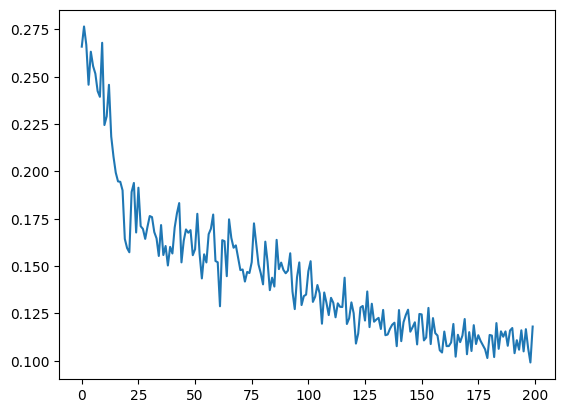

100%|██████████| 99/99 [00:45<00:00,  2.16it/s]


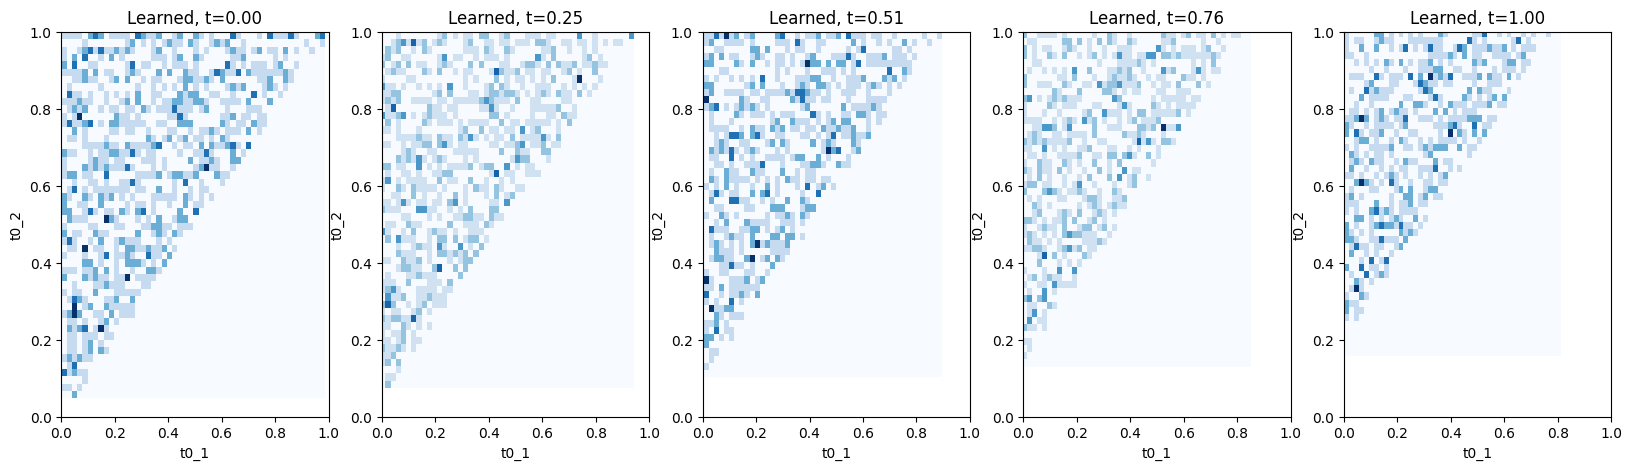

/tmp/ipykernel_15845/397013081.py:83: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


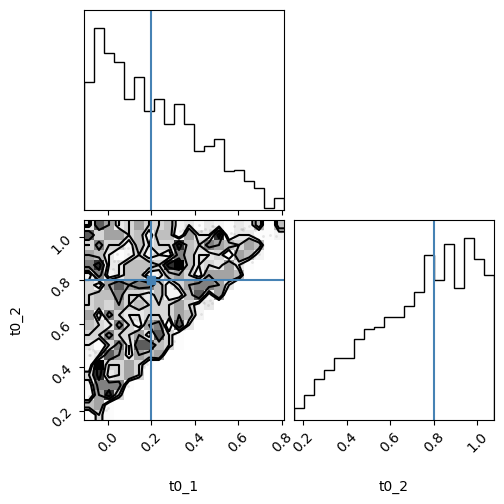

In [ ]:
# --------------------------------------------- #
#   Plot Marginal Path of Learned Vector Field  #
# --------------------------------------------- #
plt.plot(losses)
plt.show()
# generate one instance of simulated data to guide prior samples with

# fixed model parameters (NOTE: Should be same as used during training in PairedPosterior)
N = 2
time = np.linspace(0, 1.0, 1000)
amp  = 25.0
rise = 0.03
skew = 5
ybkg = 5.0
true_t0 = [0.2, 0.8] # NOTE: this has to obey the prior! (i.e. t0_1 < t0_2 < ... < t0_n)

# generate simulated data for one burst
burstparams = {
    't0'   : true_t0, 
    'amp'  : [amp, amp],
    'rise' : [rise, rise],
    'skew' : [skew, skew]
}

model = Model(
    time=time,
    ncomp=N, 
    burstparams=burstparams, 
    ybkg=ybkg
    )

simulator = BurstSimulator(model)
x_counts = simulator.simulate_burst() 

num_samples = 1000  # number of prior samples to transform 
num_marginals = 5   # number of snapshots

# use same data for all prior samples
simulation_time_resolution = 1000
simulations = torch.zeros((num_samples, simulation_time_resolution)).to(device)

for row_nr in range(len(simulations)):
    simulations[row_nr, :] = torch.Tensor(x_counts)

# Initialize ODE solver
solver = EulerODESolver(vector_field)
ts = torch.linspace(0, 1, 100).to(device)

# simulate ODE starting from x0   # TODO: should simulation be from the one used in training? 
x0 = path.p_simple.sample(num_samples)
xts = solver.solve_with_trajectory(x0, ts.view(1, -1, 1).expand(num_samples,-1,1), y=simulations)

# only save num_marginals snapshots 
record_every_idxs = record_every(len(ts), len(ts) // (num_marginals - 1))
xts = xts[:,record_every_idxs,:]

# plot snapshots of marginal path
plt.figure(figsize=(20, 5))

for idx in range(xts.shape[1]):
    xx = xts[:,idx,:]
    t = ts.cpu()[record_every_idxs[idx]]

    plt.subplot(1, num_marginals, idx + 1)
    
    plt.hist2d(x=xx[:, 0], y=xx[:, 1], bins=50, cmap='Blues')
    
    plt.title(f"Learned, t={t:.2f}")
    plt.xlabel(f"t0_1")
    plt.ylabel(f"t0_2")

    plt.xlim(0, 1)
    plt.ylim(0, 1)

plt.show()

# TODO: Plot t=1 like a corner plot ?
from corner import corner

# print(xx, type(xx), xx.shape)
fig = corner(xx.numpy(), labels=["t0_1", "t0_2"], truths=np.array(true_t0))
fig.show()